## Etapa 1 — Importações e carregamento dos dados

In [17]:
import pandas as pd
import duckdb
import requests
import zipfile
import io
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [18]:
os.makedirs("data", exist_ok=True)

#CDC
cdc_path = "data/cdc_dados.csv"
if os.path.exists(cdc_path):
    print("CDC já baixado, carregando do disco...")
    df_cdc = pd.read_csv(cdc_path, low_memory=False)
else:
    print("Baixando CDC...")
    url_cdc = "https://data.cdc.gov/api/views/hn4x-zwk7/rows.csv?accessType=DOWNLOAD"
    r = requests.get(url_cdc)
    df_cdc = pd.read_csv(io.BytesIO(r.content), low_memory=False)
    df_cdc.to_csv(cdc_path, index=False)
    print("Salvo em data/cdc_dados.csv")
print(f"CDC  → {df_cdc.shape[0]:,} linhas x {df_cdc.shape[1]} colunas")

#USDA 
usda_path  = "data/FMAP-Data.csv"
readme_path = "data/FMAP-ReadMe.txt"

if os.path.exists(usda_path):
    print("\nUSDA já baixado, carregando do disco...")
    df_usda = pd.read_csv(usda_path)
else:
    print("\nBaixando USDA...")
    url_usda = "https://www.ers.usda.gov/media/5400/food-at-home-monthly-area-prices-2012-to-2018.zip?v=24363"
    r = requests.get(url_usda)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        print(f"Arquivos no ZIP: {z.namelist()}")
        # Salvar CSV
        csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
        with z.open(csv_name) as f:
            df_usda = pd.read_csv(f)
        df_usda.to_csv(usda_path, index=False)
        print("Salvo em data/FMAP-Data.csv")
        # Salvar README
        txt_name = [f for f in z.namelist() if f.endswith(".txt")][0]
        with z.open(txt_name) as f:
            readme_content = f.read()
        with open(readme_path, "wb") as f:
            f.write(readme_content)
        print("Salvo em data/FMAP-ReadMe.txt")

print(f"USDA → {df_usda.shape[0]:,} linhas x {df_usda.shape[1]} colunas")
print(f"\nArquivos em data/: {os.listdir('data')}")

Baixando CDC...
Salvo em data/cdc_dados.csv
CDC  → 110,880 linhas x 33 colunas

Baixando USDA...
Arquivos no ZIP: ['FMAP-Data.csv', 'FMAP-ReadMe.txt']
Salvo em data/FMAP-Data.csv
Salvo em data/FMAP-ReadMe.txt
USDA → 1,020,600 linhas x 6 colunas

Arquivos em data/: ['cdc_dados.csv', 'FMAP-Data.csv', 'FMAP-ReadMe.txt']
CDC já baixado, carregando do disco...
CDC  → 110,880 linhas x 33 colunas

USDA já baixado, carregando do disco...
USDA → 1,020,600 linhas x 6 colunas

Arquivos em data/: ['cdc_dados.csv', 'FMAP-Data.csv', 'FMAP-ReadMe.txt', 'graficos']


## Etapa 2 — Registrar tabelas no DuckDB

In [19]:
con = duckdb.connect()

con.register("cdc_raw", df_cdc)
con.register("usda_raw", df_usda)

print("Tabelas disponíveis no DuckDB:")
display(con.execute("SHOW TABLES").df())

Tabelas disponíveis no DuckDB:


,name
0,cdc_raw
1,usda_raw


Tabelas disponíveis no DuckDB:


,name
0,cdc_raw
1,usda_raw


## Etapa 3 — Exploração do CDC via SQL

In [20]:
print("1. Valores de Class:")
display(con.execute("""
    SELECT DISTINCT Class FROM cdc_raw ORDER BY Class
""").df())

print("2. Valores de StratificationCategory1:")
display(con.execute("""
    SELECT DISTINCT StratificationCategory1, COUNT(*) AS n
    FROM cdc_raw GROUP BY StratificationCategory1 ORDER BY n DESC
""").df())

print("3. Valores de QuestionID dentro de 'Obesity / Weight Status':")
display(con.execute("""
    SELECT DISTINCT QuestionID, Question
    FROM cdc_raw
    WHERE Class = 'Obesity / Weight Status'
    ORDER BY QuestionID
""").df())

print("4. Valores de Stratification1 quando categoria = 'Income':")
display(con.execute("""
    SELECT DISTINCT Stratification1, COUNT(*) AS n
    FROM cdc_raw
    WHERE StratificationCategory1 = 'Income'
    GROUP BY Stratification1 ORDER BY Stratification1
""").df())

print("5. Anos disponíveis:")
display(con.execute("""
    SELECT DISTINCT YearStart FROM cdc_raw ORDER BY YearStart
""").df())

print("6. Localizações que serão excluídas:")
display(con.execute("""
    SELECT DISTINCT LocationAbbr FROM cdc_raw
    WHERE LocationAbbr IN ('US', 'PR', 'GU', 'VI')
""").df())

1. Valores de Class:


,Class
0,Fruits and Vegetables
1,Obesity / Weight Status
2,Physical Activity


2. Valores de StratificationCategory1:


,StratificationCategory1,n
0,Race/Ethnicity,31680
1,Income,27720
2,Age (years),23760
3,Education,15840
4,Sex,7920
5,Total,3960


3. Valores de QuestionID dentro de 'Obesity / Weight Status':


...

,Stratification1,n
0,"$15,000 - $24,999",3960
1,"$25,000 - $34,999",3960
2,"$35,000 - $49,999",3960
3,"$50,000 - $74,999",3960
4,"$75,000 or greater",3960
5,Data not reported,3960
6,"Less than $15,000",3960


5. Anos disponíveis:


,YearStart
0,2011
1,2012
2,2013
3,2014
4,2015
5,2016
6,2017
7,2018
8,2019
9,2020


6. Localizações que serão excluídas:


,LocationAbbr
0,US
1,GU
2,VI
3,PR


## Etapa 4 — Limpeza e filtragem do CDC via SQL

In [21]:
# Tabela 1: população total, sem segmentação por renda
cdc_geral = con.execute("""
    SELECT
        YearStart    AS Year,
        LocationAbbr AS State,
        QuestionID,
        Data_Value   AS Obesity_Rate
    FROM cdc_raw
    WHERE
        Class                       = 'Obesity / Weight Status'
        AND StratificationCategory1 = 'Total'
        AND YearStart               BETWEEN 2012 AND 2018
        AND Data_Value              IS NOT NULL
        AND LocationAbbr            NOT IN ('US', 'PR', 'GU', 'VI')
    ORDER BY Year, State, QuestionID
""").df()

# Tabela 2: segmentada por faixa de renda
cdc_renda = con.execute("""
    SELECT
        YearStart       AS Year,
        LocationAbbr    AS State,
        QuestionID,
        Stratification1 AS Income_Group,
        Data_Value      AS Obesity_Rate
    FROM cdc_raw
    WHERE
        Class                       = 'Obesity / Weight Status'
        AND StratificationCategory1 = 'Income'
        AND QuestionID              = 'Q036'
        AND Stratification1         != 'Data not reported'
        AND YearStart               BETWEEN 2012 AND 2018
        AND Data_Value              IS NOT NULL
        AND LocationAbbr            NOT IN ('US', 'PR', 'GU', 'VI')
    ORDER BY Year, State, Income_Group
""").df()

con.register("cdc_geral", cdc_geral)
con.register("cdc_renda", cdc_renda)

print(f"cdc_geral → {cdc_geral.shape[0]:,} linhas x {cdc_geral.shape[1]} colunas")
print(f"cdc_renda → {cdc_renda.shape[0]:,} linhas x {cdc_renda.shape[1]} colunas")

display(cdc_geral.head(6))
display(cdc_renda.head(6))

cdc_geral → 714 linhas x 4 colunas
cdc_renda → 2,142 linhas x 5 colunas


,Year,State,QuestionID,Obesity_Rate
0,2012,AK,Q036,25.7
1,2012,AK,Q037,39.1
2,2012,AL,Q036,33.0
3,2012,AL,Q037,34.8
4,2012,AR,Q036,34.5
5,2012,AR,Q037,34.2


,Year,State,QuestionID,Income_Group,Obesity_Rate
0,2012,AK,Q036,"$15,000 - $24,999",24.2
1,2012,AK,Q036,"$25,000 - $34,999",24.0
2,2012,AK,Q036,"$35,000 - $49,999",27.3
3,2012,AK,Q036,"$50,000 - $74,999",28.4
4,2012,AK,Q036,"$75,000 or greater",26.4
5,2012,AK,Q036,"Less than $15,000",29.4


cdc_geral → 714 linhas x 4 colunas
cdc_renda → 2,142 linhas x 5 colunas


,Year,State,QuestionID,Obesity_Rate
0,2012,AK,Q036,25.7
1,2012,AK,Q037,39.1
2,2012,AL,Q036,33.0
3,2012,AL,Q037,34.8
4,2012,AR,Q036,34.5
5,2012,AR,Q037,34.2


,Year,State,QuestionID,Income_Group,Obesity_Rate
0,2012,AK,Q036,"$15,000 - $24,999",24.2
1,2012,AK,Q036,"$25,000 - $34,999",24.0
2,2012,AK,Q036,"$35,000 - $49,999",27.3
3,2012,AK,Q036,"$50,000 - $74,999",28.4
4,2012,AK,Q036,"$75,000 or greater",26.4
5,2012,AK,Q036,"Less than $15,000",29.4


## Etapa 5 — Exploração do USDA via SQL

In [22]:
print("1. Colunas e amostra:")
display(df_usda.head(3))

print("\n2. Atributos disponíveis (tipo de valor medido):")
display(con.execute("""
    SELECT DISTINCT Attribute, COUNT(*) AS n
    FROM usda_raw
    GROUP BY Attribute
    ORDER BY n DESC
""").df())

print("\n3. Anos disponíveis:")
display(con.execute("""
    SELECT DISTINCT Year FROM usda_raw ORDER BY Year
""").df())

print("\n4. Regiões disponíveis:")
display(con.execute("""
    SELECT DISTINCT Metroregion_code, COUNT(*) AS n
    FROM usda_raw
    GROUP BY Metroregion_code
    ORDER BY Metroregion_code
""").df())

print("\n5. Quantos códigos de alimento (EFPG_code) existem:")
display(con.execute("""
    SELECT COUNT(DISTINCT EFPG_code) AS total_codigos
    FROM usda_raw
""").df())

# Quantos EFPG_codes existem e qual a faixa de valores
print("Faixa de códigos de alimento:")
display(con.execute("""
    SELECT 
        MIN(EFPG_code) AS codigo_min,
        MAX(EFPG_code) AS codigo_max,
        COUNT(DISTINCT EFPG_code) AS total
    FROM usda_raw
""").df())

print("\nTodos os EFPG_codes disponíveis:")
# Forçar exibição de todas as linhas
pd.set_option('display.max_rows', 100)

display(con.execute("""
    SELECT DISTINCT EFPG_code
    FROM usda_raw
    ORDER BY EFPG_code
""").df())

1. Colunas e amostra:


,Year,Month,EFPG_code,Metroregion_code,Attribute,Value
0,2012,1,10000,0,Purchase_dollars_wtd,2.493734e+08
1,2012,1,10000,0,Purchase_grams_wtd,4.875195e+10
2,2012,1,10000,0,Purchase_dollars_unwtd,1.629852e+08



2. Atributos disponíveis (tipo de valor medido):


,Attribute,n
0,Purchase_dollars_unwtd,113400
1,Purchase_grams_unwtd,113400
2,Purchase_dollars_wtd,113400
3,Purchase_grams_wtd,113400
4,Price_index_GEKS,113400
5,Unit_value_mean_unwtd,113400
6,Unit_value_mean_wtd,113400
7,Unit_value_se_wtd,113400
8,Number_stores,113400



3. Anos disponíveis:


...

,total_codigos
0,90


Faixa de códigos de alimento:


,codigo_min,codigo_max,total
0,10000,78000,90



Todos os EFPG_codes disponíveis:


,EFPG_code
0,10000
1,10025
2,10050
3,10075
4,15000
5,15025
6,15050
7,15075
8,20000
9,20075


## Etapa 6 — Classificação e filtragem do USDA via SQL

Usamos `CASE WHEN` para classificar cada código como `healthy` ou `processed`.

In [23]:
# ── Etapa 6 — Classificação e filtragem do USDA ───────────────────────────────

usda_filtrado = con.execute("""
    SELECT
        Year,
        Month,
        Metroregion_code,
        EFPG_code,
        Value,
        CASE
            WHEN EFPG_code IN (
                -- Grãos integrais
                10000, 10025, 10050, 10075,
                -- Vegetais (todas as formas)
                20000, 20075,
                21500, 21525, 21550, 21575,
                23000, 23075,
                24500, 24525, 24550, 24575,
                26000, 26525, 26550, 26575,
                27500, 27550, 27575,
                29000, 29025, 29050, 29075,
                -- Frutas (todas as formas)
                30000, 30025, 30050, 30075, 30090,
                -- Sucos 100%
                35000, 35050, 35075,
                -- Laticínios com gordura reduzida
                43000, 43030, 43060,
                -- Carnes não processadas
                50000, 50050,
                51500, 51550,
                -- Peixes e frutos do mar
                53000, 53050,
                -- Nozes e sementes
                54500, 54550,
                -- Ovos
                57500,
                -- Tofu
                59000
            ) THEN 'healthy'
            WHEN EFPG_code IN (
                -- Grãos não integrais
                15000, 15025, 15050, 15075,
                -- Queijo processado
                46050,
                -- Carnes processadas
                56000,
                -- Refeições prontas
                60000, 62500, 65000, 67500,
                -- Bebidas adoçadas
                72000, 72020, 72040, 72050,
                -- Doces e sobremesas
                73000, 73010, 73020, 73030, 73040, 73050, 73060,
                -- Salgadinhos não integrais
                75050
            ) THEN 'processed'
            ELSE NULL  -- neutros: excluídos da análise
        END AS Food_Type
    FROM usda_raw
    WHERE
        Attribute        = 'Unit_value_mean_wtd'
        AND Metroregion_code IN (1, 2, 3, 4)
        AND Food_Type    IS NOT NULL
    ORDER BY Year, Metroregion_code, EFPG_code
""").df()

con.register("usda_filtrado", usda_filtrado)

print(f"Linhas antes:  {len(df_usda):,}")
print(f"Linhas depois: {len(usda_filtrado):,}")
print("\nDistribuição por tipo:")
display(con.execute("""
    SELECT Food_Type, COUNT(DISTINCT EFPG_code) AS qtd_codigos, COUNT(*) AS total_linhas
    FROM usda_filtrado
    GROUP BY Food_Type
""").df())
display(usda_filtrado.head(8))

Linhas antes:  1,020,600
Linhas depois: 23,520

Distribuição por tipo:


,Food_Type,qtd_codigos,total_linhas
0,processed,22,7392
1,healthy,48,16128


,Year,Month,Metroregion_code,EFPG_code,Value,Food_Type
0,2012,1,1,10000,0.551337,healthy
1,2012,2,1,10000,0.552195,healthy
2,2012,3,1,10000,0.549603,healthy
3,2012,4,1,10000,0.548377,healthy
4,2012,5,1,10000,0.545741,healthy
5,2012,6,1,10000,0.544072,healthy
6,2012,7,1,10000,0.546840,healthy
7,2012,8,1,10000,0.542625,healthy


Linhas antes:  1,020,600
Linhas depois: 23,520

Distribuição por tipo:


,Food_Type,qtd_codigos,total_linhas
0,healthy,48,16128
1,processed,22,7392


,Year,Month,Metroregion_code,EFPG_code,Value,Food_Type
0,2012,1,1,10000,0.551337,healthy
1,2012,2,1,10000,0.552195,healthy
2,2012,3,1,10000,0.549603,healthy
3,2012,4,1,10000,0.548377,healthy
4,2012,5,1,10000,0.545741,healthy
5,2012,6,1,10000,0.544072,healthy
6,2012,7,1,10000,0.546840,healthy
7,2012,8,1,10000,0.542625,healthy


## Etapa 7 — Agregação anual do USDA via SQL

O USDA é mensal e o CDC é anual. Calculamos a média anual por região e tipo.

In [24]:
usda_anual = con.execute("""
    SELECT
        Year,
        Metroregion_code,
        ROUND(AVG(CASE WHEN Food_Type = 'healthy'   THEN Value END), 6) AS Price_Healthy,
        ROUND(AVG(CASE WHEN Food_Type = 'processed' THEN Value END), 6) AS Price_Processed,
        ROUND(
            AVG(CASE WHEN Food_Type = 'healthy'   THEN Value END) /
            AVG(CASE WHEN Food_Type = 'processed' THEN Value END)
        , 6) AS Price_Ratio
    FROM usda_filtrado
    GROUP BY Year, Metroregion_code
    ORDER BY Year, Metroregion_code
""").df()

con.register("usda_anual", usda_anual)

print(f"Shape: {usda_anual.shape}")
display(usda_anual)

Shape: (28, 5)


,Year,Metroregion_code,Price_Healthy,Price_Processed,Price_Ratio
0,2012,1,0.510638,0.539922,0.945763
1,2012,2,0.468235,0.495799,0.944405
2,2012,3,0.474816,0.504146,0.941823
3,2012,4,0.483893,0.533498,0.907020
4,2013,1,0.522589,0.545663,0.957715
5,2013,2,0.477446,0.501980,0.951127
6,2013,3,0.483863,0.509419,0.949833
7,2013,4,0.498220,0.542291,0.918732
8,2014,1,0.529767,0.551243,0.961042
9,2014,2,0.489560,0.513403,0.953559


Shape: (28, 5)


,Year,Metroregion_code,Price_Healthy,Price_Processed,Price_Ratio
0,2012,1,0.510638,0.539922,0.945763
1,2012,2,0.468235,0.495799,0.944405
2,2012,3,0.474816,0.504146,0.941823
3,2012,4,0.483893,0.533498,0.907020
4,2013,1,0.522589,0.545663,0.957715
5,2013,2,0.477446,0.501980,0.951127
6,2013,3,0.483863,0.509419,0.949833
7,2013,4,0.498220,0.542291,0.918732
8,2014,1,0.529767,0.551243,0.961042
9,2014,2,0.489560,0.513403,0.953559


## Etapa 8 — Tabela de mapeamento estado → região

In [25]:
mapeamento = [
    *[(s, 1) for s in ["CT","ME","MA","NH","NJ","NY","PA","RI","VT"]],
    *[(s, 2) for s in ["IL","IN","IA","KS","MI","MN","MO","NE","ND","OH","SD","WI"]],
    *[(s, 3) for s in ["AL","AR","DE","DC","FL","GA","KY","LA","MD","MS","NC","OK","SC","TN","TX","VA","WV"]],
    *[(s, 4) for s in ["AK","AZ","CA","CO","HI","ID","MT","NV","NM","OR","UT","WA","WY"]],
]

df_mapeamento = pd.DataFrame(mapeamento, columns=["State", "Metroregion_code"])
con.register("state_region", df_mapeamento)

print(f"Total de estados mapeados: {len(df_mapeamento)}")
print("\nDistribuição por região:")
display(con.execute("""
    SELECT Metroregion_code, COUNT(*) AS estados
    FROM state_region
    GROUP BY Metroregion_code
    ORDER BY Metroregion_code
""").df())

# Verificar se algum estado do CDC ficou de fora do mapeamento
print("\nEstados no CDC que NÃO estão no mapeamento (deveria ser zero):")
display(con.execute("""
    SELECT DISTINCT c.State
    FROM cdc_geral c
    LEFT JOIN state_region sr ON c.State = sr.State
    WHERE sr.State IS NULL
""").df())

Total de estados mapeados: 51

Distribuição por região:


,Metroregion_code,estados
0,1,9
1,2,12
2,3,17
3,4,13



Estados no CDC que NÃO estão no mapeamento (deveria ser zero):


,State


Total de estados mapeados: 51

Distribuição por região:


,Metroregion_code,estados
0,1,9
1,2,12
2,3,17
3,4,13



Estados no CDC que NÃO estão no mapeamento (deveria ser zero):


,State


## Etapa 9 — Tabela analítica via SQL

JOIN entre CDC, mapeamento de regiões e USDA em uma única query.

In [26]:
# ── Etapa 9 — Tabela analítica final ──────────────────────────────────────────

# Tabela 1: para análise de preços × obesidade (H1 e H2)
con.execute("""
    CREATE OR REPLACE TABLE analitico_precos AS
    SELECT
        c.Year,
        c.State,
        c.QuestionID,
        sr.Metroregion_code,
        ROUND(c.Obesity_Rate,    2) AS Obesity_Rate,
        ROUND(u.Price_Healthy,   6) AS Price_Healthy,
        ROUND(u.Price_Processed, 6) AS Price_Processed,
        ROUND(u.Price_Ratio,     6) AS Price_Ratio
    FROM      cdc_geral    c
    JOIN      state_region sr ON c.State = sr.State
    JOIN      usda_anual   u  ON c.Year  = u.Year
                              AND sr.Metroregion_code = u.Metroregion_code
    ORDER BY  c.Year, c.State, c.QuestionID
""")

# Tabela 2: para análise de renda × obesidade (H3)
con.execute("""
    CREATE OR REPLACE TABLE analitico_renda AS
    SELECT
        c.Year,
        c.State,
        c.Income_Group,
        sr.Metroregion_code,
        ROUND(c.Obesity_Rate,    2) AS Obesity_Rate,
        ROUND(u.Price_Healthy,   6) AS Price_Healthy,
        ROUND(u.Price_Processed, 6) AS Price_Processed,
        ROUND(u.Price_Ratio,     6) AS Price_Ratio
    FROM      cdc_renda    c
    JOIN      state_region sr ON c.State = sr.State
    JOIN      usda_anual   u  ON c.Year  = u.Year
                              AND sr.Metroregion_code = u.Metroregion_code
    ORDER BY  c.Year, c.State, c.Income_Group
""")

# Carregar como DataFrames para uso no Python/visualizações
df_analitico_precos = con.execute("SELECT * FROM analitico_precos").df()
df_analitico_renda  = con.execute("SELECT * FROM analitico_renda").df()

print(f"analitico_precos → {df_analitico_precos.shape[0]:,} linhas x {df_analitico_precos.shape[1]} colunas")
print(f"analitico_renda  → {df_analitico_renda.shape[0]:,} linhas x {df_analitico_renda.shape[1]} colunas")

print("\nNulos em analitico_precos:", df_analitico_precos.isnull().sum().sum())
print("Nulos em analitico_renda: ", df_analitico_renda.isnull().sum().sum())

print("\nTabelas no DuckDB:")
display(con.execute("SHOW TABLES").df())

display(df_analitico_precos.head(6))
display(df_analitico_renda.head(6))

analitico_precos → 714 linhas x 8 colunas
analitico_renda  → 2,142 linhas x 8 colunas

Nulos em analitico_precos: 0
Nulos em analitico_renda:  0

Tabelas no DuckDB:


,name
0,analitico_precos
1,analitico_renda
2,cdc_geral
3,cdc_raw
4,cdc_renda
5,state_region
6,usda_anual
7,usda_filtrado
8,usda_raw


,Year,State,QuestionID,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,Q036,4,25.7,0.483893,0.533498,0.907020
1,2012,AK,Q037,4,39.1,0.483893,0.533498,0.907020
2,2012,AL,Q036,3,33.0,0.474816,0.504146,0.941823
3,2012,AL,Q037,3,34.8,0.474816,0.504146,0.941823
4,2012,AR,Q036,3,34.5,0.474816,0.504146,0.941823
5,2012,AR,Q037,3,34.2,0.474816,0.504146,0.941823


,Year,State,Income_Group,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,"$15,000 - $24,999",4,24.2,0.483893,0.533498,0.90702
1,2012,AK,"$25,000 - $34,999",4,24.0,0.483893,0.533498,0.90702
2,2012,AK,"$35,000 - $49,999",4,27.3,0.483893,0.533498,0.90702
3,2012,AK,"$50,000 - $74,999",4,28.4,0.483893,0.533498,0.90702
4,2012,AK,"$75,000 or greater",4,26.4,0.483893,0.533498,0.90702
5,2012,AK,"Less than $15,000",4,29.4,0.483893,0.533498,0.90702


analitico_precos → 714 linhas x 8 colunas
analitico_renda  → 2,142 linhas x 8 colunas

Nulos em analitico_precos: 0
Nulos em analitico_renda:  0

Tabelas no DuckDB:


,name
0,analitico_precos
1,analitico_renda
2,cdc_geral
3,cdc_raw
4,cdc_renda
5,state_region
6,usda_anual
7,usda_filtrado
8,usda_raw


,Year,State,QuestionID,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,Q036,4,25.7,0.483893,0.533498,0.907020
1,2012,AK,Q037,4,39.1,0.483893,0.533498,0.907020
2,2012,AL,Q036,3,33.0,0.474816,0.504146,0.941823
3,2012,AL,Q037,3,34.8,0.474816,0.504146,0.941823
4,2012,AR,Q036,3,34.5,0.474816,0.504146,0.941823
5,2012,AR,Q037,3,34.2,0.474816,0.504146,0.941823


,Year,State,Income_Group,Metroregion_code,Obesity_Rate,Price_Healthy,Price_Processed,Price_Ratio
0,2012,AK,"$15,000 - $24,999",4,24.2,0.483893,0.533498,0.90702
1,2012,AK,"$25,000 - $34,999",4,24.0,0.483893,0.533498,0.90702
2,2012,AK,"$35,000 - $49,999",4,27.3,0.483893,0.533498,0.90702
3,2012,AK,"$50,000 - $74,999",4,28.4,0.483893,0.533498,0.90702
4,2012,AK,"$75,000 or greater",4,26.4,0.483893,0.533498,0.90702
5,2012,AK,"Less than $15,000",4,29.4,0.483893,0.533498,0.90702


## Etapa 10 — Análise exploratória via SQL

In [27]:
# ── Etapa 10 — Análise Exploratória ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Separar obesidade (Q036) e sobrepeso (Q037)
df_obesidade = con.execute("SELECT * FROM analitico_precos WHERE QuestionID = 'Q036'").df()
df_sobrepeso = con.execute("SELECT * FROM analitico_precos WHERE QuestionID = 'Q037'").df()

regioes = {1: "Nordeste", 2: "Centro-Oeste", 3: "Sul", 4: "Oeste"}
cores   = {1: "#e63946", 2: "#457b9d", 3: "#2a9d8f", 4: "#e9c46a"}

print(f"df_obesidade → {df_obesidade.shape[0]} linhas")
print(f"df_sobrepeso → {df_sobrepeso.shape[0]} linhas")
os.makedirs("data/graficos", exist_ok=True)

df_obesidade → 357 linhas
df_sobrepeso → 357 linhas
df_obesidade → 357 linhas
df_sobrepeso → 357 linhas


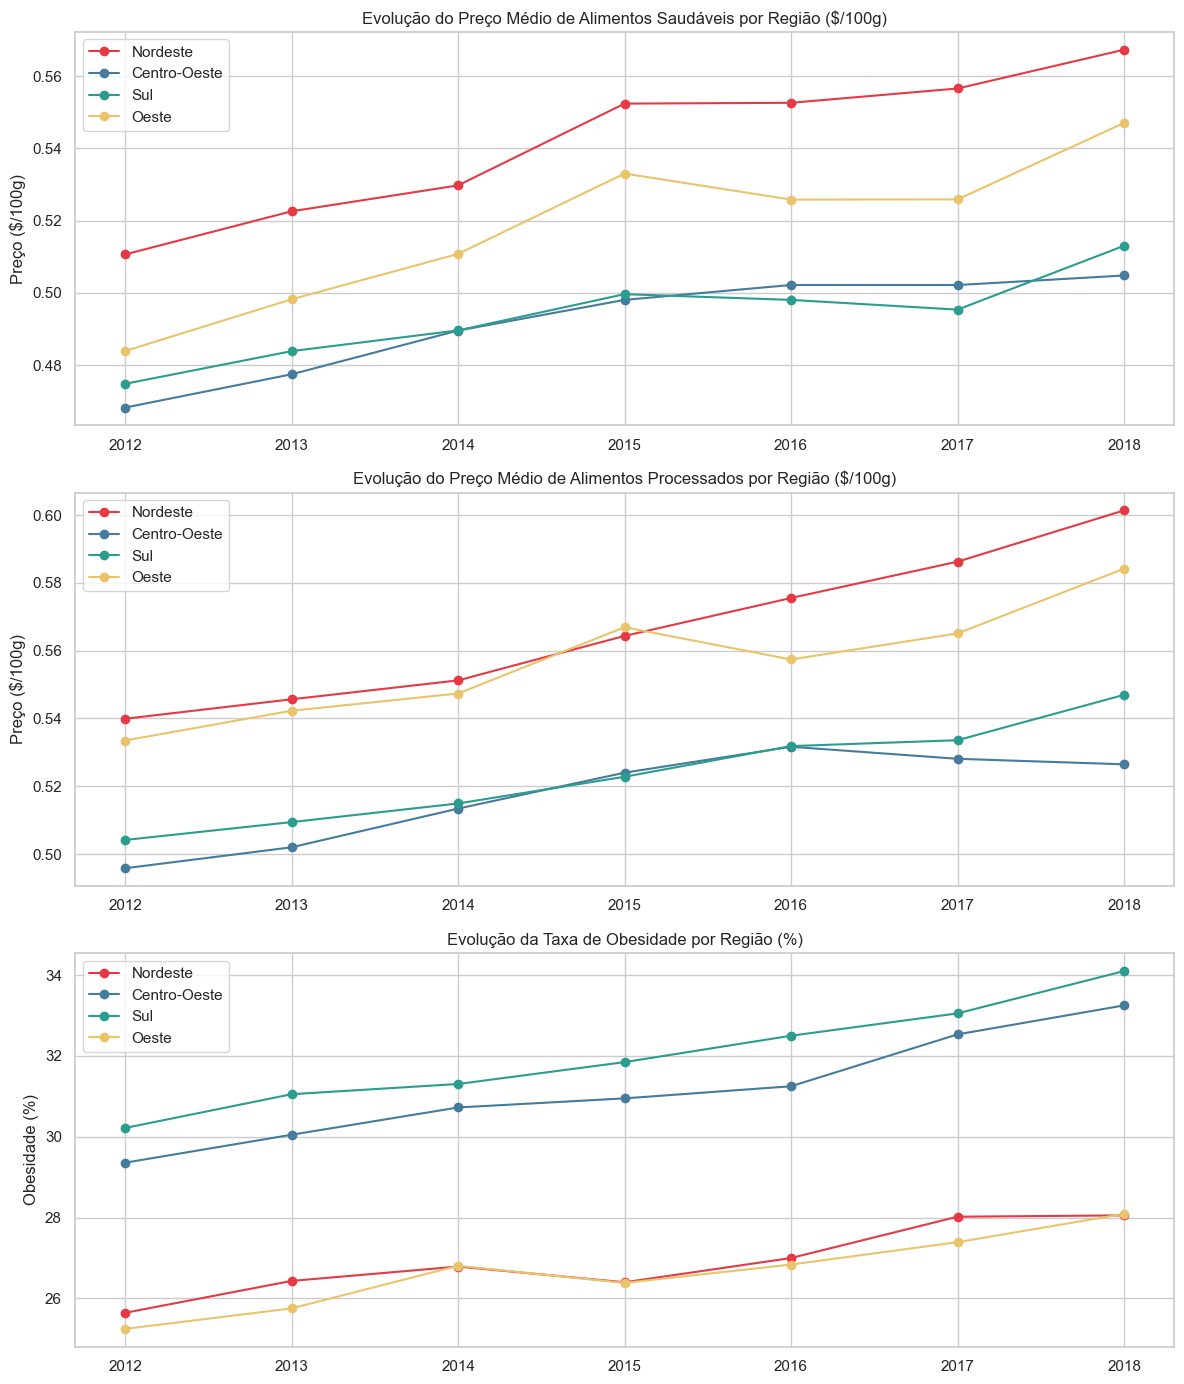

Salvo: data/graficos/fig1_evolucao_precos_obesidade.png


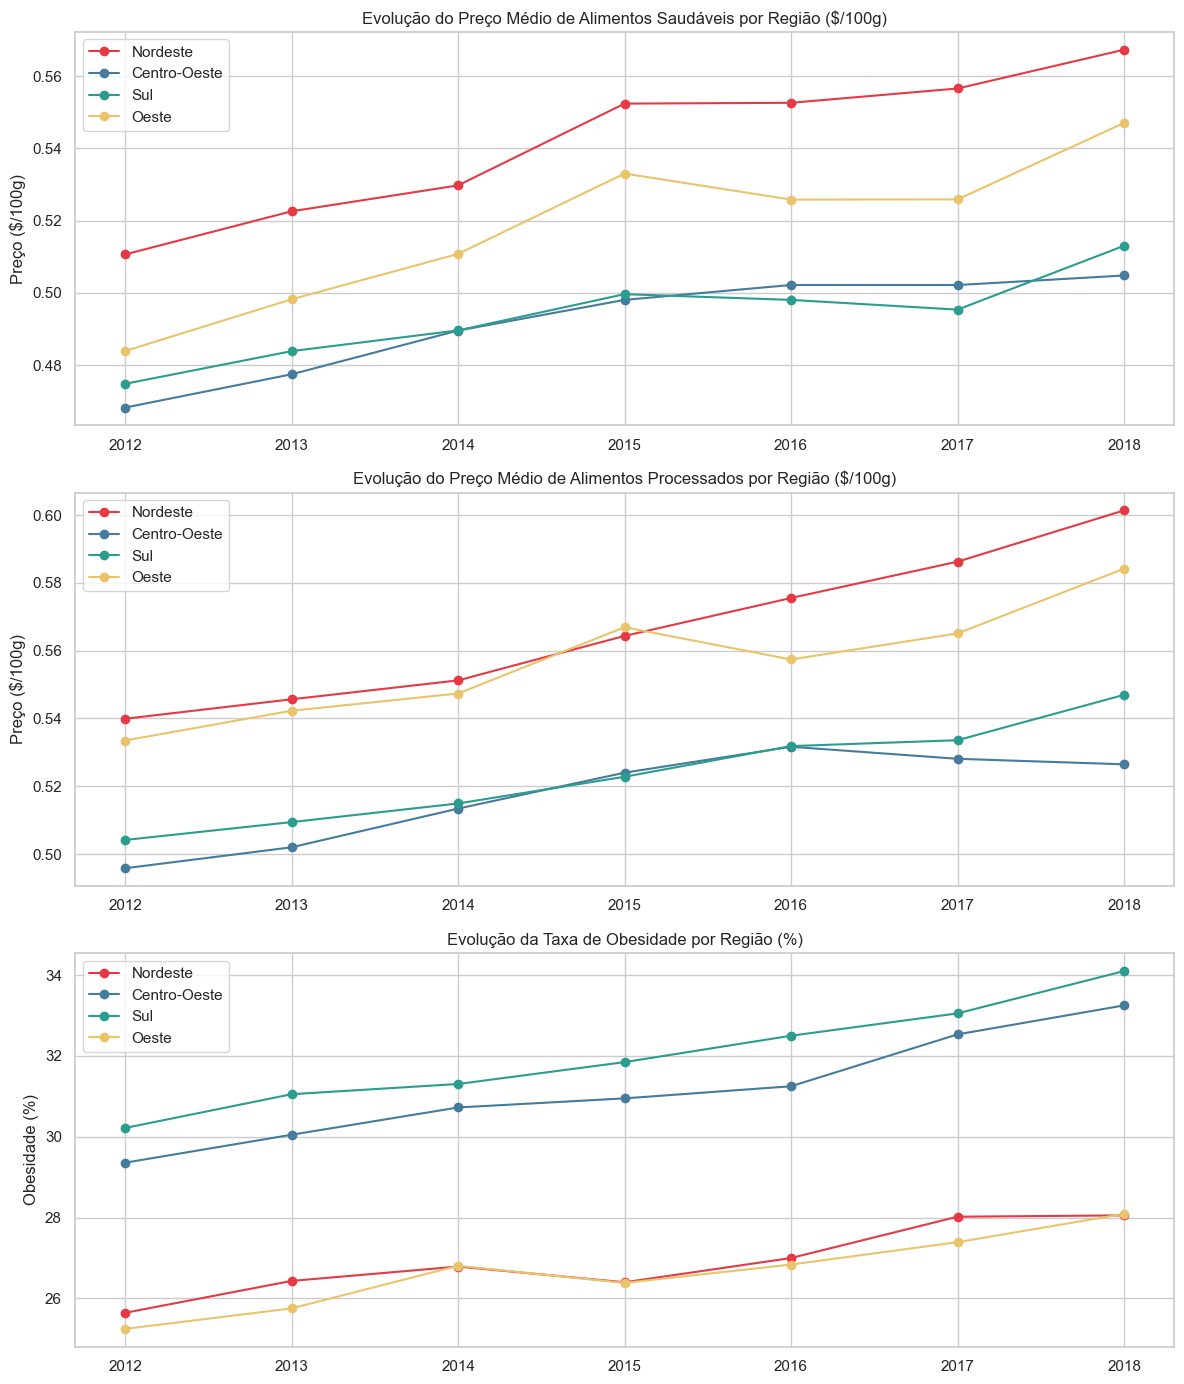

Salvo: data/graficos/fig1_evolucao_precos_obesidade.png


In [28]:
# ── Gráfico 1: Evolução anual — preços e obesidade por região (H1)
os.makedirs("data/graficos", exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Preço saudável por região ao longo do tempo
ax = axes[0]
for codigo, nome in regioes.items():
    dados = df_obesidade[df_obesidade["Metroregion_code"] == codigo].groupby("Year")["Price_Healthy"].mean()
    ax.plot(dados.index, dados.values, marker="o", label=nome, color=cores[codigo])
ax.set_title("Evolução do Preço Médio de Alimentos Saudáveis por Região ($/100g)")
ax.set_ylabel("Preço ($/100g)")
ax.legend()

# Preço processado por região ao longo do tempo
ax = axes[1]
for codigo, nome in regioes.items():
    dados = df_obesidade[df_obesidade["Metroregion_code"] == codigo].groupby("Year")["Price_Processed"].mean()
    ax.plot(dados.index, dados.values, marker="o", label=nome, color=cores[codigo])
ax.set_title("Evolução do Preço Médio de Alimentos Processados por Região ($/100g)")
ax.set_ylabel("Preço ($/100g)")
ax.legend()

# Taxa de obesidade por região ao longo do tempo
ax = axes[2]
for codigo, nome in regioes.items():
    dados = df_obesidade[df_obesidade["Metroregion_code"] == codigo].groupby("Year")["Obesity_Rate"].mean()
    ax.plot(dados.index, dados.values, marker="o", label=nome, color=cores[codigo])
ax.set_title("Evolução da Taxa de Obesidade por Região (%)")
ax.set_ylabel("Obesidade (%)")
ax.legend()

plt.tight_layout()
plt.savefig("data/graficos/fig1_evolucao_precos_obesidade.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: data/graficos/fig1_evolucao_precos_obesidade.png")

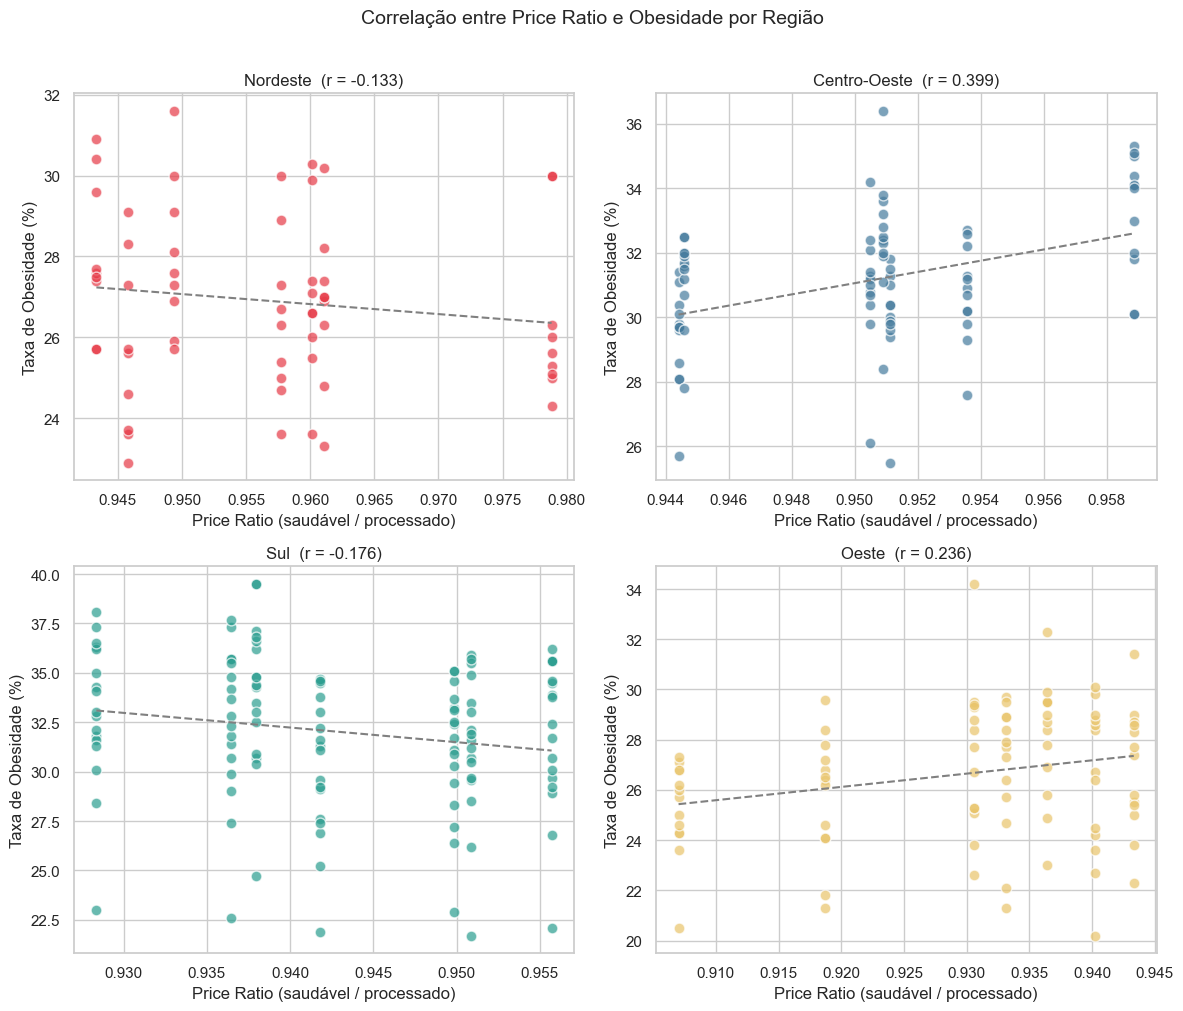

Salvo: data/graficos/fig2_correlacao_ratio_obesidade.png


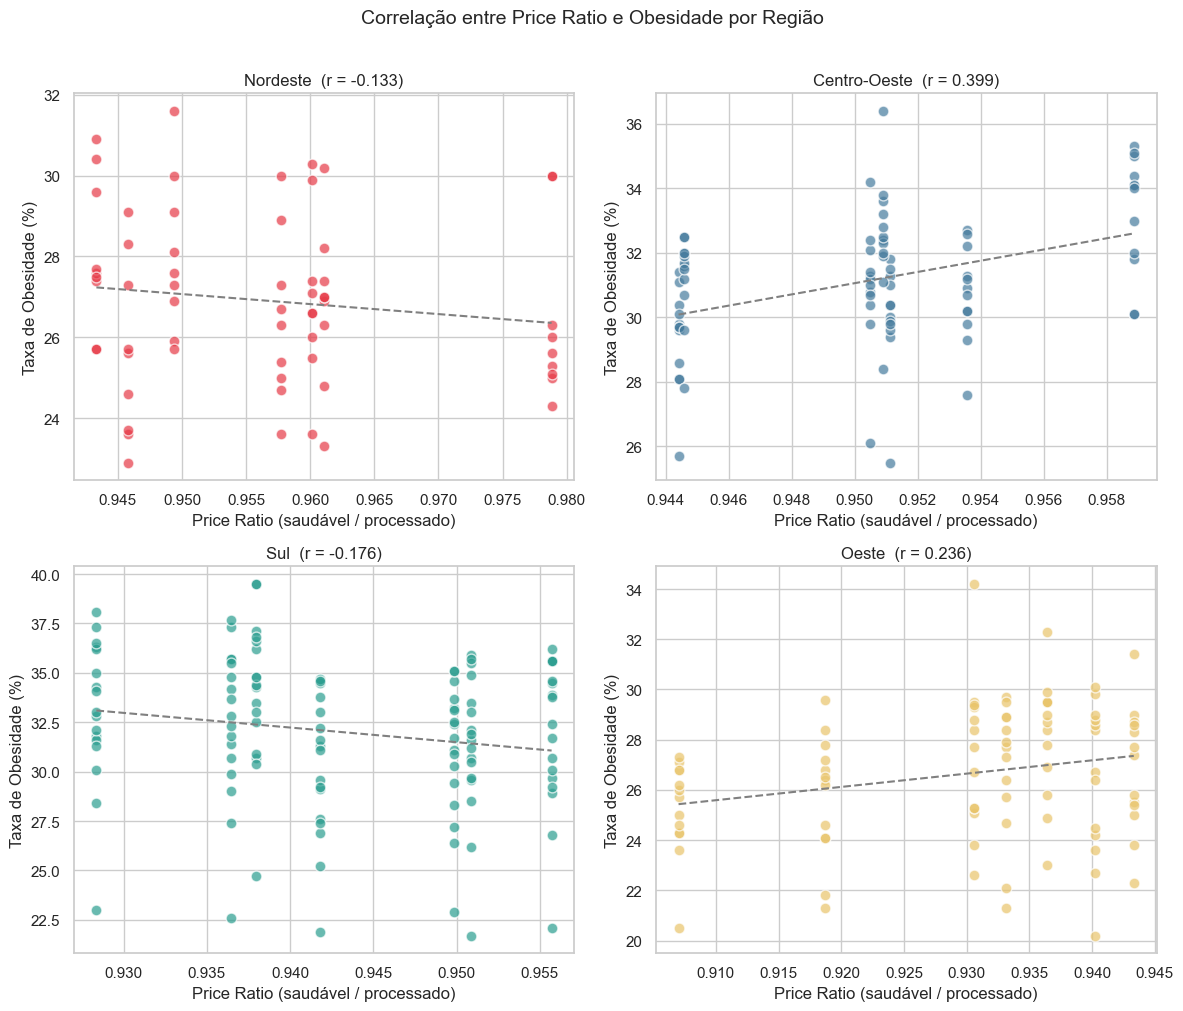

Salvo: data/graficos/fig2_correlacao_ratio_obesidade.png


In [29]:
# ── Gráfico 2: Correlação Price_Ratio × Obesity_Rate por região (H1) ──────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (codigo, nome) in enumerate(regioes.items()):
    dados = df_obesidade[df_obesidade["Metroregion_code"] == codigo]
    ax = axes[i]
    ax.scatter(dados["Price_Ratio"], dados["Obesity_Rate"],
               color=cores[codigo], alpha=0.7, edgecolors="white", s=60)
    # Linha de tendência
    z = np.polyfit(dados["Price_Ratio"], dados["Obesity_Rate"], 1)
    p = np.poly1d(z)
    x_line = sorted(dados["Price_Ratio"])
    ax.plot(x_line, p(x_line), "--", color="gray", linewidth=1.5)
    corr = dados["Price_Ratio"].corr(dados["Obesity_Rate"])
    ax.set_title(f"{nome}  (r = {corr:.3f})")
    ax.set_xlabel("Price Ratio (saudável / processado)")
    ax.set_ylabel("Taxa de Obesidade (%)")

plt.suptitle("Correlação entre Price Ratio e Obesidade por Região", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("data/graficos/fig2_correlacao_ratio_obesidade.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: data/graficos/fig2_correlacao_ratio_obesidade.png")

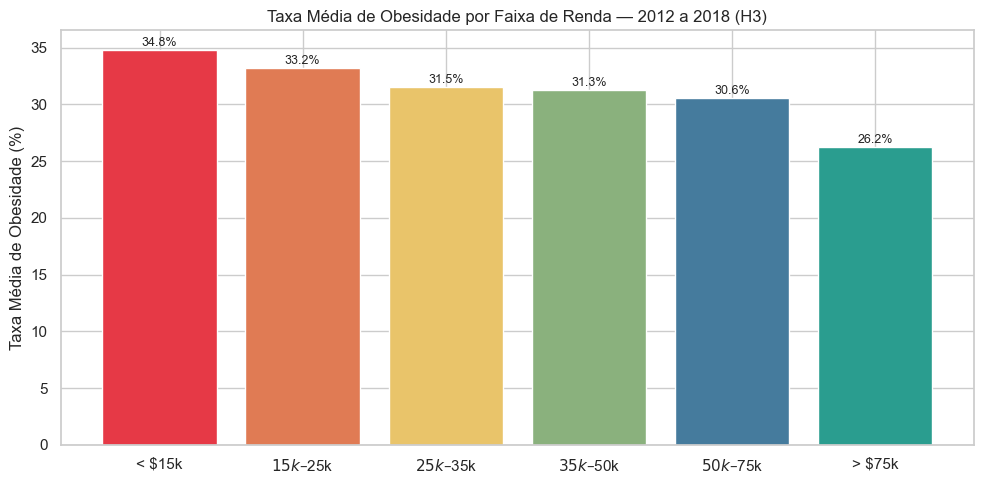

Salvo: data/graficos/fig3_obesidade_por_renda.png


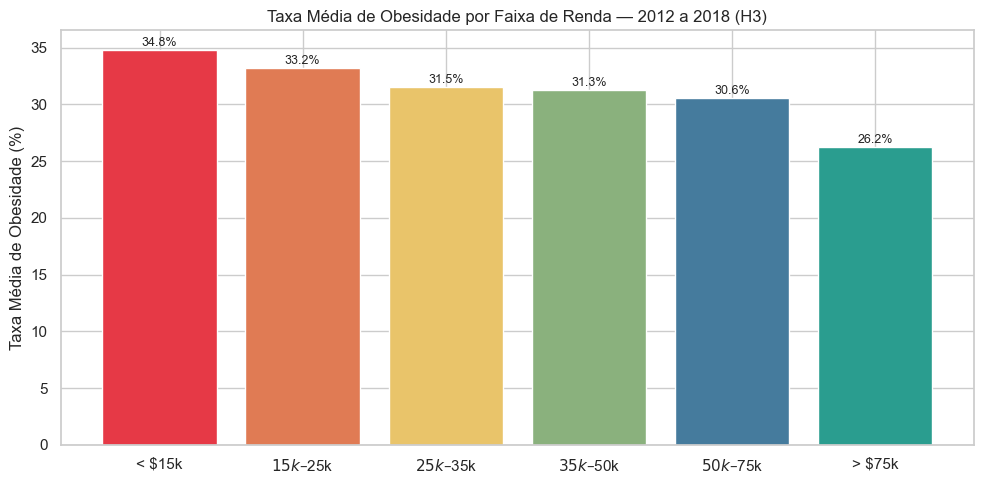

Salvo: data/graficos/fig3_obesidade_por_renda.png


In [30]:
# ── Gráfico 3: Obesidade por faixa de renda (H3) ──────────────────────────────
ordem_renda = [
    "Less than $15,000",
    "$15,000 - $24,999",
    "$25,000 - $34,999",
    "$35,000 - $49,999",
    "$50,000 - $74,999",
    "$75,000 or greater"
]

labels_renda = [
    "< $15k",
    "$15k–$25k",
    "$25k–$35k",
    "$35k–$50k",
    "$50k–$75k",
    "> $75k"
]

media_renda = (df_analitico_renda
               .groupby("Income_Group")["Obesity_Rate"]
               .mean()
               .reindex(ordem_renda))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(ordem_renda)), media_renda.values,
              color=["#e63946","#e07b54","#e9c46a","#8ab17d","#457b9d","#2a9d8f"])
ax.set_xticks(range(len(ordem_renda)))
ax.set_xticklabels(labels_renda)
ax.set_ylabel("Taxa Média de Obesidade (%)")
ax.set_title("Taxa Média de Obesidade por Faixa de Renda — 2012 a 2018 (H3)")
for bar, val in zip(bars, media_renda.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("data/graficos/fig3_obesidade_por_renda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: data/graficos/fig3_obesidade_por_renda.png")

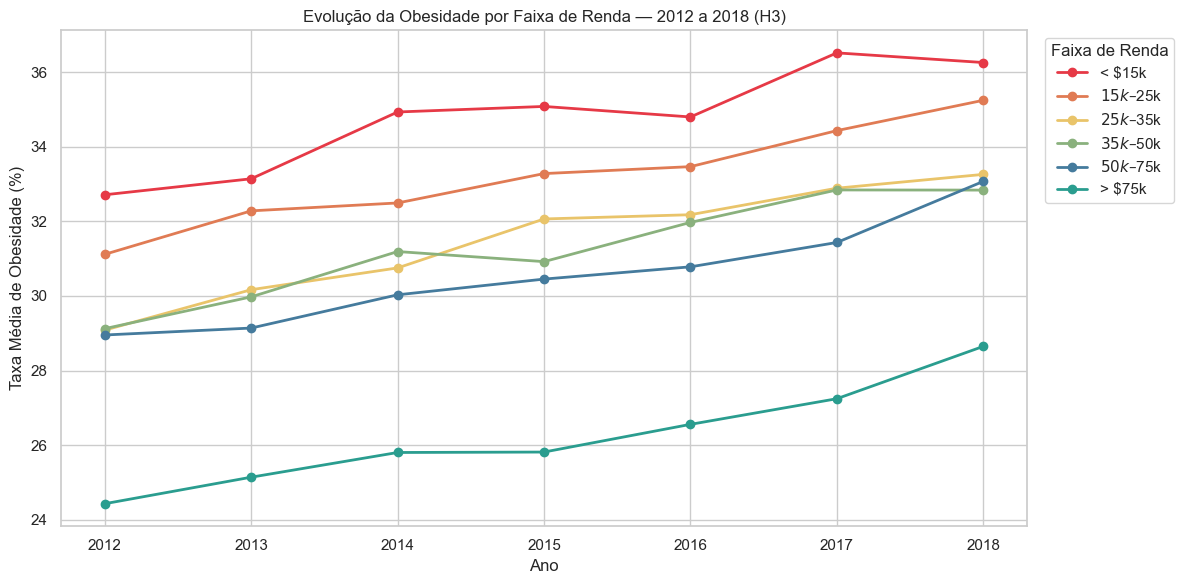

Salvo: fig4_evolucao_obesidade_renda.png


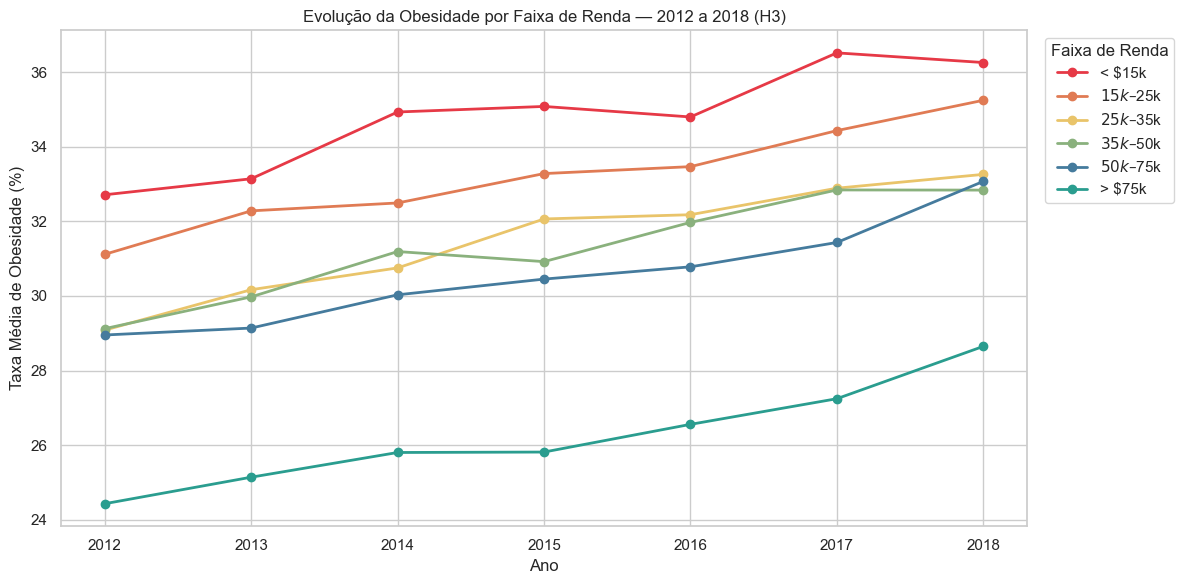

Salvo: fig4_evolucao_obesidade_renda.png


In [31]:
# ── Gráfico 4: Evolução da obesidade por faixa de renda ao longo do tempo ──────
fig, ax = plt.subplots(figsize=(12, 6))

cores_renda = {
    "Less than $15,000"  : "#e63946",
    "$15,000 - $24,999"  : "#e07b54",
    "$25,000 - $34,999"  : "#e9c46a",
    "$35,000 - $49,999"  : "#8ab17d",
    "$50,000 - $74,999"  : "#457b9d",
    "$75,000 or greater" : "#2a9d8f"
}

labels_renda_map = {
    "Less than $15,000"  : "< $15k",
    "$15,000 - $24,999"  : "$15k–$25k",
    "$25,000 - $34,999"  : "$25k–$35k",
    "$35,000 - $49,999"  : "$35k–$50k",
    "$50,000 - $74,999"  : "$50k–$75k",
    "$75,000 or greater" : "> $75k"
}

for faixa, cor in cores_renda.items():
    dados = (df_analitico_renda[df_analitico_renda["Income_Group"] == faixa]
             .groupby("Year")["Obesity_Rate"].mean())
    ax.plot(dados.index, dados.values, marker="o",
            label=labels_renda_map[faixa], color=cor, linewidth=2)

ax.set_title("Evolução da Obesidade por Faixa de Renda — 2012 a 2018 (H3)")
ax.set_ylabel("Taxa Média de Obesidade (%)")
ax.set_xlabel("Ano")
ax.legend(title="Faixa de Renda", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("data/graficos/fig4_evolucao_obesidade_renda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig4_evolucao_obesidade_renda.png")

In [32]:
# ── Etapa 10 — Correlações estatísticas (H1 e H3) ─────────────────────────────
print("=" * 55)
print("CORRELAÇÕES: Price_Ratio × Obesity_Rate por região")
print("=" * 55)

for codigo, nome in regioes.items():
    dados = df_obesidade[df_obesidade["Metroregion_code"] == codigo]
    r, p = stats.pearsonr(dados["Price_Ratio"], dados["Obesity_Rate"])
    sig = "✓ significativo" if p < 0.05 else "✗ não significativo"
    print(f"{nome:15} → r = {r:+.3f}  |  p = {p:.4f}  |  {sig}")

print()
print("=" * 55)
print("CORRELAÇÕES: Price_Healthy × Obesity_Rate por região")
print("=" * 55)

for codigo, nome in regioes.items():
    dados = df_obesidade[df_obesidade["Metroregion_code"] == codigo]
    r, p = stats.pearsonr(dados["Price_Healthy"], dados["Obesity_Rate"])
    sig = "✓ significativo" if p < 0.05 else "✗ não significativo"
    print(f"{nome:15} → r = {r:+.3f}  |  p = {p:.4f}  |  {sig}")

print()
print("=" * 55)
print("CORRELAÇÃO GERAL: Renda × Obesidade (H3)")
print("=" * 55)

# Converter faixa de renda em valor numérico ordinal
ordem_num = {
    "Less than $15,000"  : 1,
    "$15,000 - $24,999"  : 2,
    "$25,000 - $34,999"  : 3,
    "$35,000 - $49,999"  : 4,
    "$50,000 - $74,999"  : 5,
    "$75,000 or greater" : 6
}
df_analitico_renda["Income_Num"] = df_analitico_renda["Income_Group"].map(ordem_num)
r, p = stats.pearsonr(df_analitico_renda["Income_Num"], df_analitico_renda["Obesity_Rate"])
sig = "✓ significativo" if p < 0.05 else "✗ não significativo"
print(f"Renda (ordinal) × Obesidade → r = {r:+.3f}  |  p = {p:.4f}  |  {sig}")

print('Teste')

CORRELAÇÕES: Price_Ratio × Obesity_Rate por região
Nordeste        → r = -0.133  |  p = 0.2995  |  ✗ não significativo
Centro-Oeste    → r = +0.399  |  p = 0.0002  |  ✓ significativo
Sul             → r = -0.176  |  p = 0.0561  |  ✗ não significativo
Oeste           → r = +0.236  |  p = 0.0242  |  ✓ significativo

CORRELAÇÕES: Price_Healthy × Obesity_Rate por região
Nordeste        → r = +0.326  |  p = 0.0091  |  ✓ significativo
Centro-Oeste    → r = +0.542  |  p = 0.0000  |  ✓ significativo
Sul             → r = +0.300  |  p = 0.0009  |  ✓ significativo
Oeste           → r = +0.294  |  p = 0.0046  |  ✓ significativo

CORRELAÇÃO GERAL: Renda × Obesidade (H3)
Renda (ordinal) × Obesidade → r = -0.488  |  p = 0.0000  |  ✓ significativo
CORRELAÇÕES: Price_Ratio × Obesity_Rate por região
Nordeste        → r = -0.133  |  p = 0.2995  |  ✗ não significativo
Centro-Oeste    → r = +0.399  |  p = 0.0002  |  ✓ significativo
Sul             → r = -0.176  |  p = 0.0561  |  ✗ não significativo
Oeste 